# NSGD Autoscaling — Experiment Analysis

Reads experiment CSVs from the NSGD middleware and produces the graphs
needed for comparison with LSTM-PPO (Figures 2–6 from the paper).

**Files expected:**
- `logs/nsgd/request_log.csv` — per-request data
- `logs/nsgd/samples.csv` — periodic aggregates (every 30s)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.rcParams.update({
    'figure.figsize': (10, 5),
    'font.size': 12,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'lines.linewidth': 1.5,
})

LOG_DIR = 'logs/nsgd_constant_poss_7_trace'

requests = pd.read_csv(f'{LOG_DIR}/request_log.csv')
samples = pd.read_csv(f'{LOG_DIR}/samples.csv')

requests['datetime'] = pd.to_datetime(requests['timestamp'], unit='s')
samples['datetime'] = pd.to_datetime(samples['timestamp'], unit='s')

training = requests[requests['mode'] == 'training'].copy()
evaluation = requests[requests['mode'] == 'evaluation'].copy()

print(f'Request log:  {len(requests):,} rows')
print(f'  Training:   {len(training):,}')
print(f'  Evaluation: {len(evaluation):,}')
print(f'Samples:      {len(samples):,} rows')
print(f'Duration:     {(requests.timestamp.max() - requests.timestamp.min()) / 60:.1f} minutes')

Request log:  55,287 rows
  Training:   55,287
  Evaluation: 0
Samples:      264 rows
Duration:     131.7 minutes


## Figure 2 — θ Convergence Over Iterations
Un-perturbed θ values at each iteration boundary.

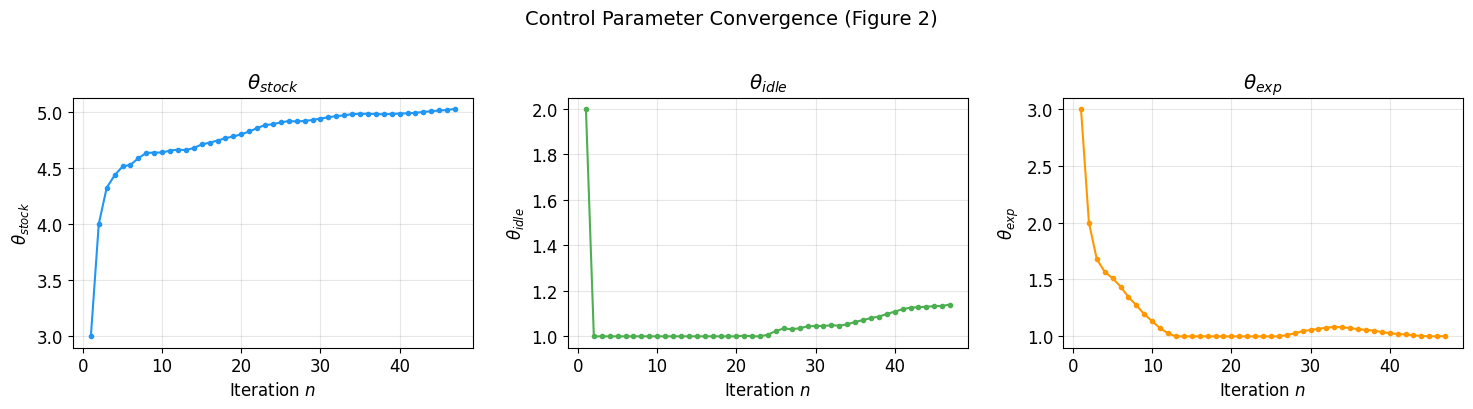

In [2]:
# Extract one row per iteration (first row after iteration changes)
convergence = (
    training
    .dropna(subset=['iteration', 'theta_base_stock'])
    .groupby('iteration')
    .first()
    [['theta_base_stock', 'theta_base_idle', 'theta_base_exp']]
    .reset_index()
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col, label, color in zip(
    axes,
    ['theta_base_stock', 'theta_base_idle', 'theta_base_exp'],
    [r'$\theta_{stock}$', r'$\theta_{idle}$', r'$\theta_{exp}$'],
    ['#2196F3', '#4CAF50', '#FF9800'],
):
    ax.plot(convergence['iteration'], convergence[col], color=color, marker='o', markersize=3)
    ax.set_xlabel('Iteration $n$')
    ax.set_ylabel(label)
    ax.set_title(label)

fig.suptitle('Control Parameter Convergence (Figure 2)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f'{LOG_DIR}/fig2_theta_convergence.png', dpi=150, bbox_inches='tight')
plt.show()

In [3]:
# Check the last 10 iterations
recent = convergence.tail(10)
for col in ['theta_base_stock', 'theta_base_idle', 'theta_base_exp']:
    cv = recent[col].std() / recent[col].mean()
    print(f"{col}: cv={cv:.3f} (lower = more converged)")

theta_base_stock: cv=0.013 (lower = more converged)
theta_base_idle: cv=0.032 (lower = more converged)
theta_base_exp: cv=0.014 (lower = more converged)


## NSGD Cost Over Time (Training)
Rolling average of per-request cost during training.

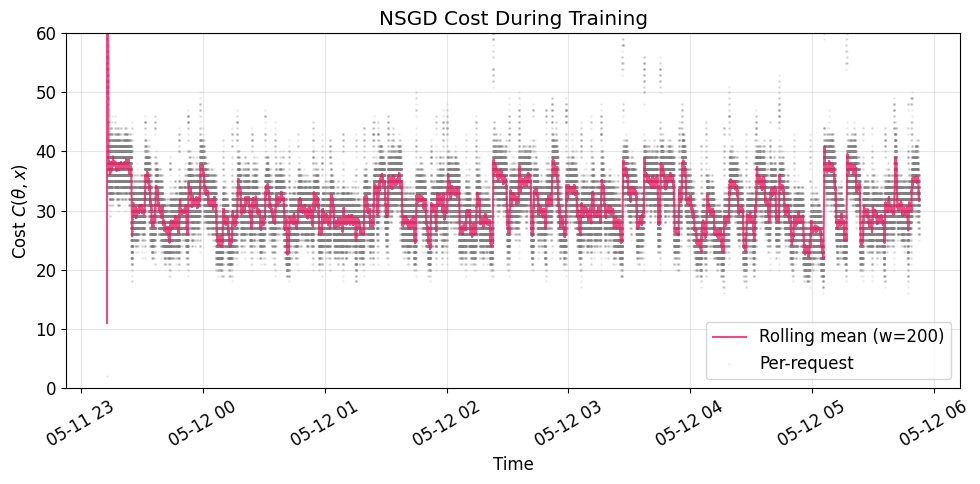

In [4]:
window = min(200, len(training) // 5) if len(training) > 10 else 1

fig, ax = plt.subplots()
ax.plot(
    training['datetime'],
    training['nsgd_cost'].rolling(window=window, min_periods=1).mean(),
    color='#E91E63', alpha=0.8, label=f'Rolling mean (w={window})'
)
ax.scatter(
    training['datetime'], training['nsgd_cost'],
    s=1, alpha=0.1, color='gray', label='Per-request'
)
ax.set_ylim(0, 60) 
ax.set_xlabel('Time')
ax.set_ylabel('Cost $C(\\theta, x)$')
ax.set_title('NSGD Cost During Training')
ax.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(f'{LOG_DIR}/training_cost_over_time.png', dpi=150, bbox_inches='tight')
plt.show()

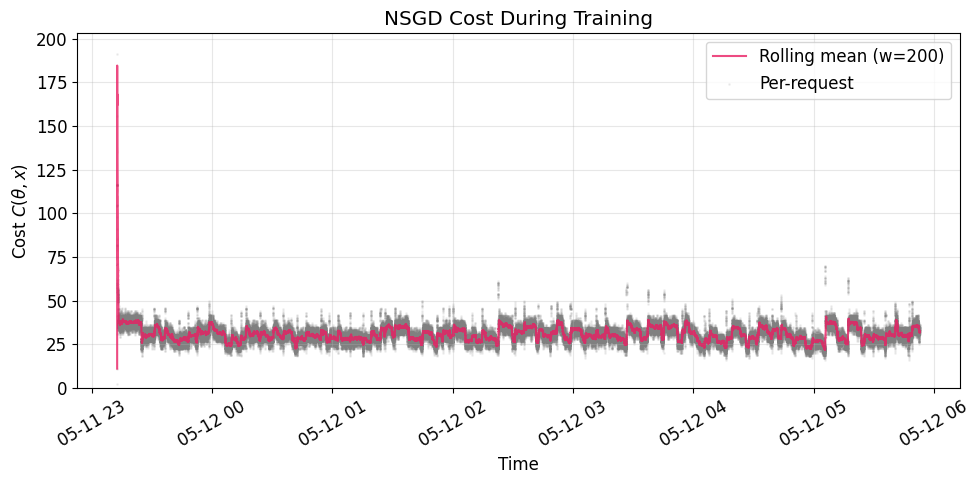

In [5]:
# 1. Calculate the rolling window size
window = min(200, len(training) // 5) if len(training) > 10 else 1

# 2. Calculate the rolling mean explicitly so we can measure it
rolling_mean = training['nsgd_cost'].rolling(window=window, min_periods=1).mean()

# 3. Set up the plot
fig, ax = plt.subplots()

# 4. Plot the smoothed rolling mean line
ax.plot(
    training['datetime'],
    rolling_mean,
    color='#E91E63', alpha=0.8, label=f'Rolling mean (w={window})'
)

# 5. Plot the raw scatter points
ax.scatter(
    training['datetime'], training['nsgd_cost'],
    s=1, alpha=0.1, color='gray', label='Per-request'
)

# --- THE NEW PERFECT DYNAMIC FIX ---
# Find the highest point of the rolling mean line and add a 10% buffer to the top.
# This ensures the entire line is always visible without being squashed!
line_max = rolling_mean.max()
ax.set_ylim(bottom=0, top=line_max * 1.1)
# -----------------------------------

ax.set_xlabel('Time')
ax.set_ylabel('Cost $C(\\theta, x)$')
ax.set_title('NSGD Cost During Training')
ax.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(f'{LOG_DIR}/training_cost_over_time.png', dpi=150, bbox_inches='tight')
plt.show()

## Cost Per Iteration (Averaged)
Average cost within each NSGD iteration — shows learning progress.

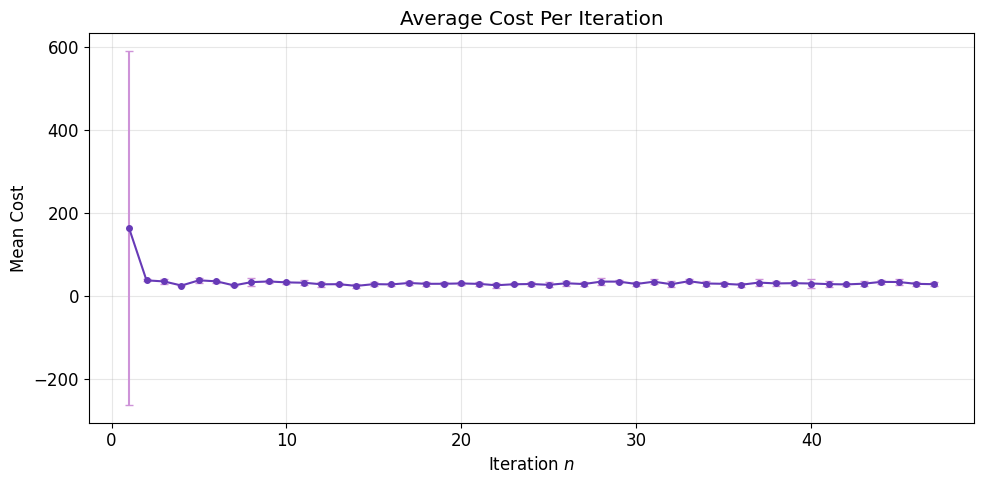

In [6]:
cost_per_iter = (
    training
    .dropna(subset=['iteration'])
    .groupby('iteration')['nsgd_cost']
    .agg(['mean', 'std', 'count'])
    .reset_index()
)

fig, ax = plt.subplots()
ax.errorbar(
    cost_per_iter['iteration'], cost_per_iter['mean'],
    yerr=cost_per_iter['std'], fmt='-o', markersize=4,
    capsize=3, color='#673AB7', ecolor='#CE93D8',
)
ax.set_xlabel('Iteration $n$')
ax.set_ylabel('Mean Cost')
ax.set_title('Average Cost Per Iteration')
plt.tight_layout()
plt.savefig(f'{LOG_DIR}/cost_per_iteration.png', dpi=150, bbox_inches='tight')
plt.show()

## Evaluation Cost Distribution
Cost under the learned (fixed) policy — this is the number reported in Figures 3/4.

In [5]:
if len(evaluation) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].hist(evaluation['nsgd_cost'], bins=50, color='#009688', edgecolor='white')
    axes[0].axvline(evaluation['nsgd_cost'].mean(), color='red', linestyle='--',
                    label=f'Mean = {evaluation["nsgd_cost"].mean():.2f}')
    axes[0].set_xlabel('Cost $C(\\theta, x)$')
    axes[0].set_ylabel('Count')
    axes[0].set_title('Evaluation Cost Distribution')
    axes[0].legend()

    axes[1].plot(evaluation['datetime'], evaluation['nsgd_cost'].rolling(50, min_periods=1).mean(),
                color='#009688')
    axes[1].set_xlabel('Time')
    axes[1].set_ylabel('Cost (rolling mean)')
    axes[1].set_title('Evaluation Cost Over Time')
    plt.xticks(rotation=30)

    plt.tight_layout()
    plt.savefig(f'{LOG_DIR}/evaluation_cost.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f'Evaluation cost: mean={evaluation["nsgd_cost"].mean():.2f}, '
          f'std={evaluation["nsgd_cost"].std():.2f}, '
          f'n={len(evaluation)}')
else:
    print('No evaluation data yet. Run: curl -X POST http://localhost:8000/mode/evaluate')

No evaluation data yet. Run: curl -X POST http://localhost:8000/mode/evaluate


## Replica Count Over Time
How many pods were active — shows the scaling behavior.

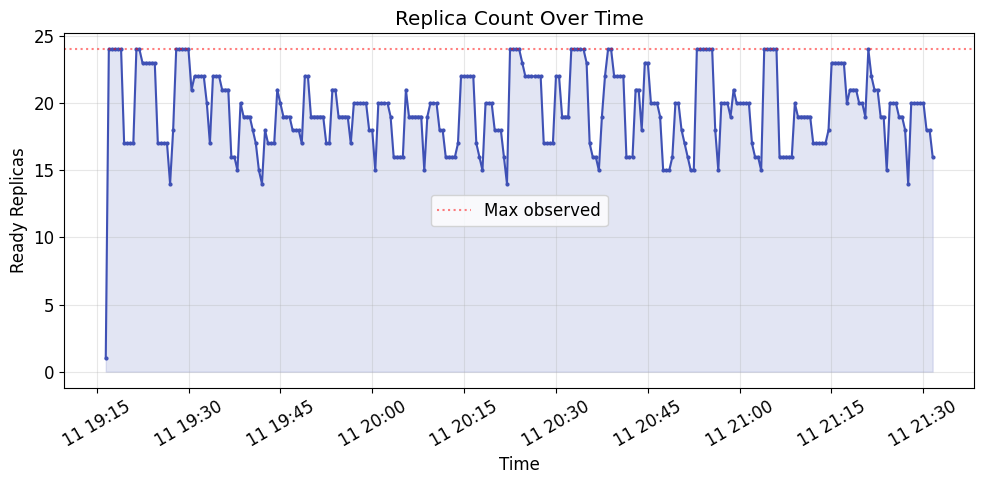

In [7]:
fig, ax = plt.subplots()

ax.plot(samples['datetime'], samples['replicas'], color='#3F51B5', marker='.', markersize=4)
ax.fill_between(samples['datetime'], 0, samples['replicas'], alpha=0.15, color='#3F51B5')
ax.axhline(y=requests['ready_pods'].max(), color='red', linestyle=':', alpha=0.5, label='Max observed')
ax.set_xlabel('Time')
ax.set_ylabel('Ready Replicas')
ax.set_title('Replica Count Over Time')
ax.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(f'{LOG_DIR}/replicas_over_time.png', dpi=150, bbox_inches='tight')
plt.show()

## Cold Start and Rejection Rates
Per-request cold start probability and rejection rate over time.

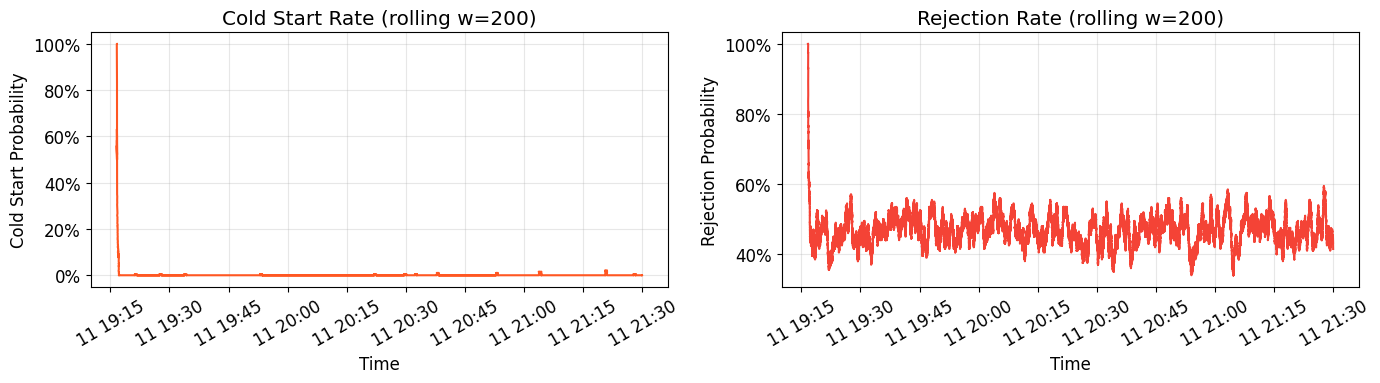

Overall cold start rate: 0.0006 (34 / 55999)
Overall rejection rate:  0.4690 (26265 / 55999)


In [8]:
# Use the dataset with most rows (training or all)
data = requests.copy()
window = min(200, len(data) // 5) if len(data) > 10 else 1

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Cold start rate
cold_start_roll = data['is_cold_start'].astype(float).rolling(window, min_periods=1).mean()
axes[0].plot(data['datetime'], cold_start_roll, color='#FF5722')
axes[0].set_xlabel('Time')
axes[0].set_ylabel('Cold Start Probability')
axes[0].set_title(f'Cold Start Rate (rolling w={window})')
axes[0].yaxis.set_major_formatter(ticker.PercentFormatter(1.0))

# Rejection rate
rejection_roll = data['rejected'].astype(float).rolling(window, min_periods=1).mean()
axes[1].plot(data['datetime'], rejection_roll, color='#F44336')
axes[1].set_xlabel('Time')
axes[1].set_ylabel('Rejection Probability')
axes[1].set_title(f'Rejection Rate (rolling w={window})')
axes[1].yaxis.set_major_formatter(ticker.PercentFormatter(1.0))

for ax in axes:
    plt.sca(ax)
    plt.xticks(rotation=30)

plt.tight_layout()
plt.savefig(f'{LOG_DIR}/cold_start_rejection.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Overall cold start rate: {data["is_cold_start"].mean():.4f} ({data["is_cold_start"].sum()} / {len(data)})')
print(f'Overall rejection rate:  {data["rejected"].mean():.4f} ({data["rejected"].sum()} / {len(data)})')

## Response Latency Distribution
End-to-end latency as seen by the client (proxy → gateway → function → proxy).

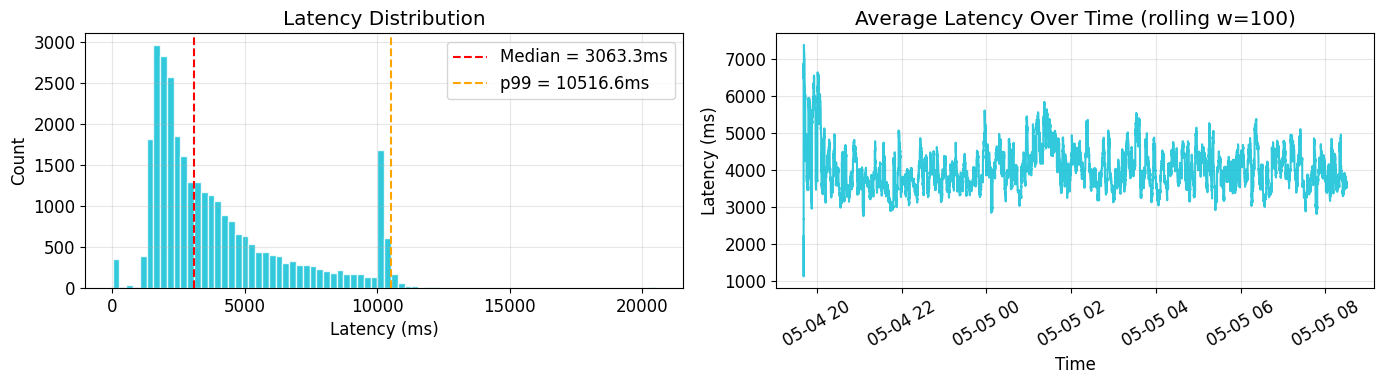

Latency: mean=4032.8ms, median=3063.3ms, p95=10137.6ms, p99=10516.6ms


In [ ]:
latency_ms = requests['latency_seconds'] * 1000

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram
axes[0].hist(latency_ms, bins=80, color='#00BCD4', edgecolor='white', alpha=0.8)
axes[0].axvline(latency_ms.median(), color='red', linestyle='--',
                label=f'Median = {latency_ms.median():.1f}ms')
axes[0].axvline(latency_ms.quantile(0.99), color='orange', linestyle='--',
                label=f'p99 = {latency_ms.quantile(0.99):.1f}ms')
axes[0].set_xlabel('Latency (ms)')
axes[0].set_ylabel('Count')
axes[0].set_title('Latency Distribution')
axes[0].legend()

# Over time
window = min(100, len(requests) // 5) if len(requests) > 10 else 1
axes[1].plot(requests['datetime'], latency_ms.rolling(window, min_periods=1).mean(),
             color='#00BCD4', alpha=0.8)
axes[1].set_xlabel('Time')
axes[1].set_ylabel('Latency (ms)')
axes[1].set_title(f'Average Latency Over Time (rolling w={window})')
plt.sca(axes[1])
plt.xticks(rotation=30)

plt.tight_layout()
plt.savefig(f'{LOG_DIR}/latency.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Latency: mean={latency_ms.mean():.1f}ms, median={latency_ms.median():.1f}ms, '
      f'p95={latency_ms.quantile(0.95):.1f}ms, p99={latency_ms.quantile(0.99):.1f}ms')

## Throughput and Execution Time (env.py Observables)
Same metrics the LSTM-PPO agent sees — from periodic Prometheus samples.

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(samples['datetime'], samples['avg_execution_time'] * 1000, color='#795548', marker='.')
axes[0].set_ylabel('Avg Execution Time (ms)')
axes[0].set_title('Function Execution Time')

axes[1].plot(samples['datetime'], samples['throughput'], color='#4CAF50', marker='.')
axes[1].set_ylabel('Throughput (%)')
axes[1].set_title('Throughput (% Successful)')
axes[1].set_ylim(0, 105)

axes[2].bar(samples['datetime'], samples['requests'], width=0.001, color='#607D8B')
axes[2].set_ylabel('Requests per Window')
axes[2].set_title(f'Request Count (per {samples.attrs.get("window", 30)}s window)')

for ax in axes:
    ax.set_xlabel('Time')
    plt.sca(ax)
    plt.xticks(rotation=30)

plt.tight_layout()
plt.savefig(f'{LOG_DIR}/env_observables.png', dpi=150, bbox_inches='tight')
plt.show()

## CPU and Memory Utilization
Normalized by function resource requests — same as env.py.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(samples['datetime'], samples['avg_cpu'], color='#E91E63', marker='.')
axes[0].set_ylabel('Normalized CPU')
axes[0].set_title('Avg CPU Utilization per Pod')
axes[0].axhline(1.0, color='red', linestyle=':', alpha=0.5, label='100% of request')
axes[0].legend()

axes[1].plot(samples['datetime'], samples['avg_mem'], color='#9C27B0', marker='.')
axes[1].set_ylabel('Normalized Memory')
axes[1].set_title('Avg Memory Utilization per Pod')
axes[1].axhline(1.0, color='red', linestyle=':', alpha=0.5, label='100% of request')
axes[1].legend()

for ax in axes:
    ax.set_xlabel('Time')
    plt.sca(ax)
    plt.xticks(rotation=30)

plt.tight_layout()
plt.savefig(f'{LOG_DIR}/cpu_mem.png', dpi=150, bbox_inches='tight')
plt.show()

## NSGD State Breakdown Over Time
Stacked view of cold, idle-on, busy, init-free, init-reserved.

In [ ]:
# Resample per-request data to 5-second bins for readability
state_cols = ['cold', 'idle_on', 'busy', 'init_free', 'init_reserved']
resampled = requests.set_index('datetime')[state_cols].resample('5s').mean().dropna()

fig, ax = plt.subplots(figsize=(12, 5))
colors = ['#BDBDBD', '#4CAF50', '#2196F3', '#FFC107', '#F44336']
ax.stackplot(
    resampled.index, *[resampled[c] for c in state_cols],
    labels=['Cold', 'Idle-On', 'Busy', 'Init-Free', 'Init-Reserved'],
    colors=colors, alpha=0.8,
)
ax.set_xlabel('Time')
ax.set_ylabel('Function Instances')
ax.set_title('System State Breakdown')
ax.legend(loc='upper right')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(f'{LOG_DIR}/state_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()

## θ Step Values Applied (Perturbed)
Actual policy parameters used for scaling during plus/minus phases.

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col, label, color in zip(
    axes,
    ['theta_stock', 'theta_idle', 'theta_exp'],
    [r'$\pi_{\theta_{stock}}$', r'$\pi_{\theta_{idle}}$', r'$\theta_{exp}$ (step)'],
    ['#2196F3', '#4CAF50', '#FF9800'],
):
    valid = training.dropna(subset=[col])
    ax.scatter(valid['datetime'], valid[col], s=2, alpha=0.3, color=color)
    ax.set_xlabel('Time')
    ax.set_ylabel(label)
    ax.set_title(label)
    plt.sca(ax)
    plt.xticks(rotation=30)

fig.suptitle('Applied θ (Perturbed) During Training', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f'{LOG_DIR}/theta_step_applied.png', dpi=150, bbox_inches='tight')
plt.show()

## NSGD Phases — Plus vs Minus Cost
Cost collected during each perturbation direction.

In [ ]:
phase_cost = (
    training
    .dropna(subset=['iteration', 'phase'])
    .groupby(['iteration', 'phase'])['nsgd_cost']
    .mean()
    .unstack(fill_value=np.nan)
    .reset_index()
)

fig, ax = plt.subplots()
if 'plus' in phase_cost.columns:
    ax.plot(phase_cost['iteration'], phase_cost['plus'],
            marker='o', markersize=4, label='Plus phase', color='#4CAF50')
if 'minus' in phase_cost.columns:
    ax.plot(phase_cost['iteration'], phase_cost['minus'],
            marker='s', markersize=4, label='Minus phase', color='#F44336')
ax.set_xlabel('Iteration $n$')
ax.set_ylabel('Mean Cost')
ax.set_title('Cost: Plus vs Minus Perturbation Phases')
ax.legend()
plt.tight_layout()
plt.savefig(f'{LOG_DIR}/phase_cost_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary Statistics Table
Key numbers for the paper — split by training and evaluation.

In [ ]:
def compute_stats(df, label):
    if len(df) == 0:
        return None
    return {
        'Phase': label,
        'Requests': len(df),
        'Mean Cost': round(df['nsgd_cost'].mean(), 2),
        'Std Cost': round(df['nsgd_cost'].std(), 2),
        'Cold Start %': round(df['is_cold_start'].mean() * 100, 2),
        'Rejection %': round(df['rejected'].mean() * 100, 2),
        'Mean Latency (ms)': round(df['latency_seconds'].mean() * 1000, 1),
        'p99 Latency (ms)': round(df['latency_seconds'].quantile(0.99) * 1000, 1),
        'Mean Replicas': round(df['ready_pods'].mean(), 1),
    }

rows = [s for s in [compute_stats(training, 'Training'), compute_stats(evaluation, 'Evaluation')] if s]
summary_df = pd.DataFrame(rows).set_index('Phase')
summary_df

## Final θ Values
The learned parameters — what would be reported in the paper.

In [10]:
last_training = training.dropna(subset=['theta_base_stock']).tail(1)

if len(last_training) > 0:
    row = last_training.iloc[0]
    print('Final learned θ (un-perturbed):')
    print(f'  θ_stock = {row["theta_base_stock"]:.4f}')
    print(f'  θ_idle  = {row["theta_base_idle"]:.4f}')
    print(f'  θ_exp   = {row["theta_base_exp"]:.4f}')
    print(f'  Iteration: {int(row["iteration"])}')
    print()
    if len(evaluation) > 0:
        print(f'Evaluation cost under this θ: {evaluation["nsgd_cost"].mean():.2f} ± {evaluation["nsgd_cost"].std():.2f}')
    else:
        print('No evaluation data. Switch to evaluation mode to measure final cost.')
else:
    print('No training data with theta values found.')

Final learned θ (un-perturbed):
  θ_stock = 3.8576
  θ_idle  = 1.1204
  θ_exp   = 4.2006
  Iteration: 86

No evaluation data. Switch to evaluation mode to measure final cost.


## Periodic Samples — NSGD Cost (from samples.csv)
Aggregated view using the same sampling window as env.py.

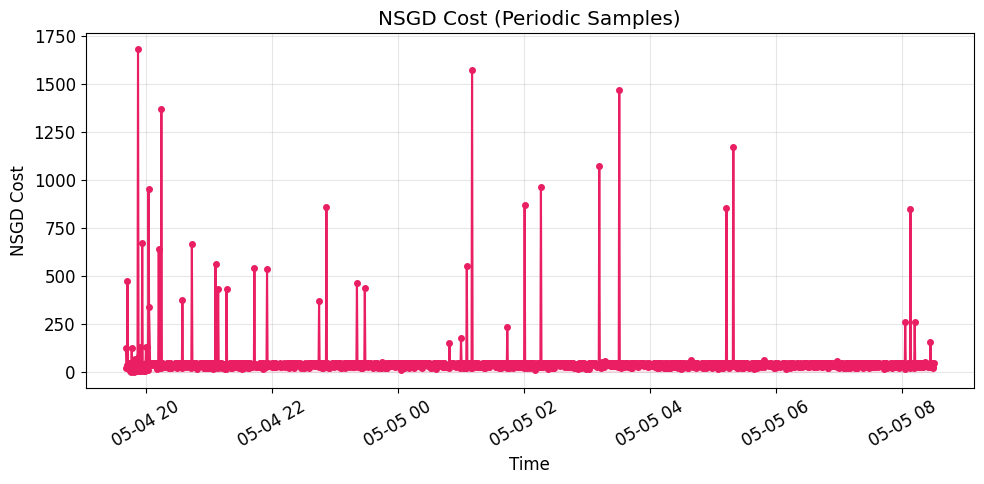

Mean cost (periodic): 50.16
Mean throughput:      92.8%
Mean replicas:        18.6


In [9]:
fig, ax = plt.subplots()
ax.plot(samples['datetime'], samples['nsgd_cost'], marker='o', markersize=4, color='#E91E63')
ax.fill_between(samples['datetime'], 0, samples['nsgd_cost'], alpha=0.1, color='#E91E63')
ax.set_xlabel('Time')
ax.set_ylabel('NSGD Cost')
ax.set_title('NSGD Cost (Periodic Samples)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(f'{LOG_DIR}/periodic_cost.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Mean cost (periodic): {samples["nsgd_cost"].mean():.2f}')
print(f'Mean throughput:      {samples["throughput"].mean():.1f}%')
print(f'Mean replicas:        {samples["replicas"].mean():.1f}')

## Save All Figures Summary

In [ ]:
import glob
saved = sorted(glob.glob(f'{LOG_DIR}/*.png'))
print(f'Saved {len(saved)} figures to {LOG_DIR}/:')
for f in saved:
    print(f'  {f}')